In [1]:
import sys
import os

sys.path.append(os.path.join('..', '..', '..'))

In [2]:
from roboflow import Roboflow
from config import ROBOFLOW_API_KEY

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace("mihailo").project("football-players-detection-3zvbc-7ocfe")
version = project.version(2)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to football-players-detection-2 in yolov11:: 100%|██████████| 1948/1948 [00:00<00:00, 7814.82it/s]


In [2]:
dataset_location = '/home/alfredo/Documents/futbol_data_science/football_analysis/models/train/object_detection/football-players-detection-2'

In [3]:
import os
import yaml

YAML_PATH = os.path.join(dataset_location,"data.yaml")

with open(YAML_PATH) as f:
     list_doc = yaml.safe_load(f)

list_doc['test'] = '../test/images'
list_doc['train'] = '../train/images'
list_doc['val'] = '../valid/images'

print(list_doc)

with open(YAML_PATH, "w") as f:
    yaml.dump(list_doc, f)

{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 4, 'names': ['ball', 'goalkeeper', 'player', 'referee'], 'roboflow': {'workspace': 'mihailo', 'project': 'football-players-detection-3zvbc-7ocfe', 'version': 2, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/mihailo/football-players-detection-3zvbc-7ocfe/dataset/2'}}


In [5]:
!yolo mode=train model=yolo11s.pt task=detect data={YAML_PATH} epochs=200 patience=20 imgsz=1280 batch=8 plots=True cache=False

Ultralytics 8.4.51 🚀 Python-3.14.4 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 7808MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/alfredo/Documents/futbol_data_science/football_analysis/models/train/object_detection/football-players-detection-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0

In [8]:
RESULTS_DIR = '/home/alfredo/Documents/futbol_data_science/football_analysis/runs/detect/train-2'

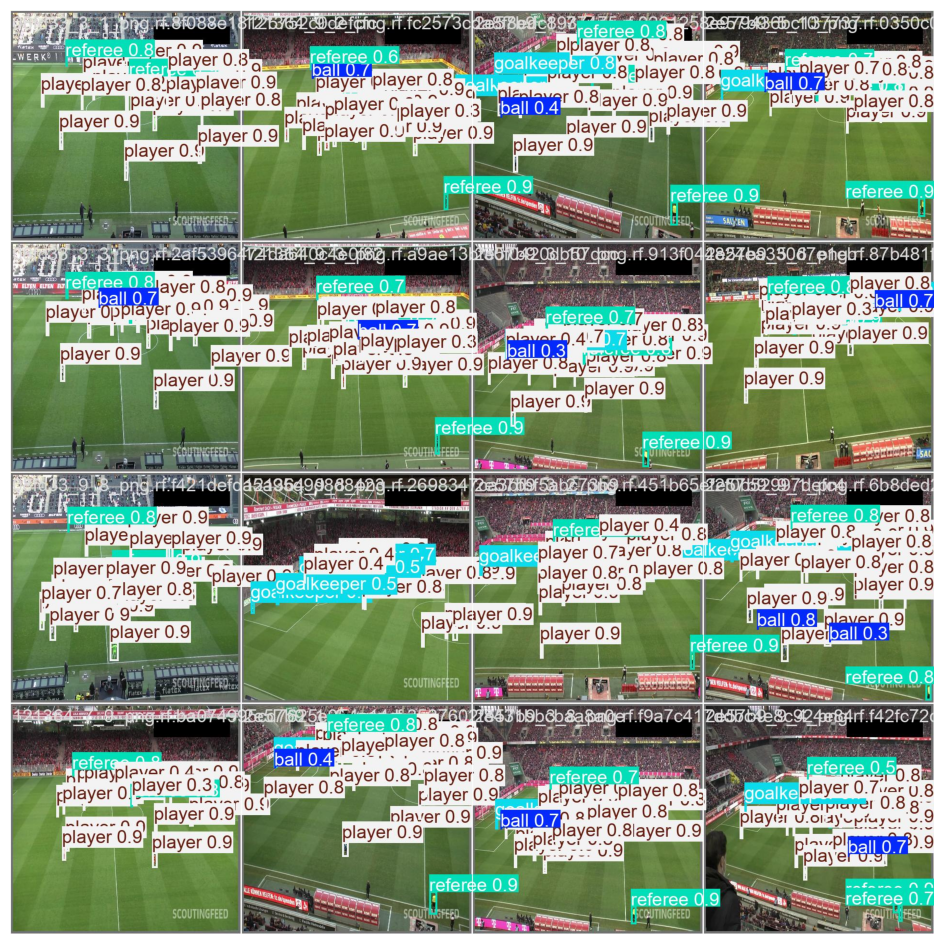

In [9]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plt.figure(figsize=(12,12))
plt.axis(False)
plt.imshow(mpimg.imread(f'{RESULTS_DIR}/val_batch0_pred.jpg'))

plt.show()


In [10]:
!yolo task=detect mode=val model={RESULTS_DIR}/weights/best.pt data={YAML_PATH}

Ultralytics 8.4.51 🚀 Python-3.14.4 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 7808MiB)
YOLO11s summary (fused): 101 layers, 9,414,348 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3853.1±842.7 MB/s, size: 173.9 KB)
val: Scanning /home/alfredo/Documents/futbol_data_science/football_analysis/models/train/object_detection/football-players-detection-2/valid/labels.cache... 49 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 49/49 8.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.8it/s 2.2s1.0s
                   all         49       1174      0.905      0.865      0.905      0.641
                  ball         45         45      0.898      0.587      0.673      0.316
            goalkeeper         38         39      0.818      0.923      0.971      0.761
                player         49        973      0.968      0.985      0.994      0.803
       

In [11]:
import os
import shutil

source_path = f'{RESULTS_DIR}/weights/best.pt'
destination_dir = '../../weights'
destination_file = os.path.join(destination_dir, 'object-detection.pt')

# Create the destination directory if it doesn't exist
os.makedirs(destination_dir, exist_ok=True)

# Move and rename the file
try:
    shutil.move(source_path, destination_file)
    print(f"File moved and renamed to {destination_file}")
except FileNotFoundError:
    print(f"Source file '{source_path}' not found.")
except Exception as e:
    print(f"Error occurred: {e}")

File moved and renamed to ../../weights/object-detection.pt
